In [ ]:
# ---------------------------------------------------------
# Cell 1: 匯入所有必要套件
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import warnings
import random
import os
import matplotlib.pyplot as plt
import optuna

from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, StackingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 補上評估指標套件 (手動防漏 CV 需要)
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, log_loss

random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')

# 1. 讀取原始資料
train_df = pd.read_csv('../data/boy or girl 2025 train_missingValue.csv')
test_df = pd.read_csv('../data/boy or girl 2025 test no ans_missingValue.csv')

c:\Users\User\Desktop\boys_or_girls\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📌 [1] 分析原始資料缺失狀態並繪製對照圖...


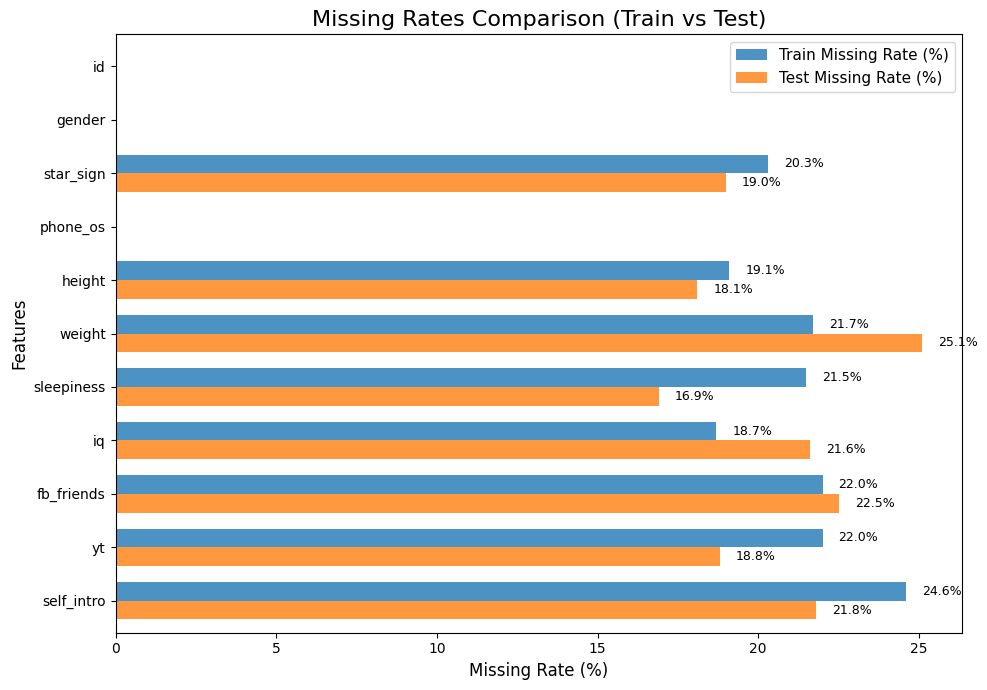


📌 [2.1] Defining physical boundaries (Values outside these ranges will be set to NaN)...

=== Table 2: Physical Boundary Filtering Thresholds by Feature ===


,Feature,Min Bound,Max Bound,Rationale
,height,100 cm,250 cm,Exclude negative values and extreme outliers (...
,weight,30 kg,200 kg,Exclude negative values and extreme outliers
,iq,50,200,Reasonable human IQ range
,sleepiness,0 hr,24 hr,Maximum 24 hours in a day
,fb_friends,0,None,Exclude negative friend counts
,yt,0,None (V4: Dynamic 99th Percentile),Exclude Excel errors (#NUM!) and negative values



📌 [3] 分別繪製 Height 與 Weight 的性別分佈...


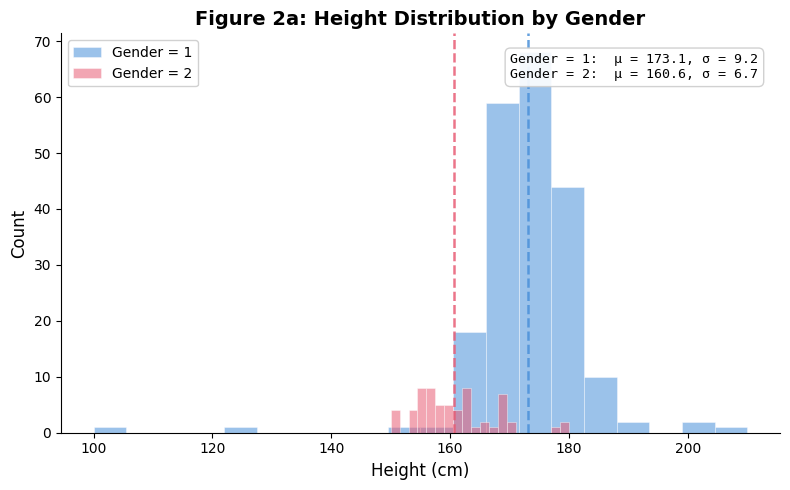

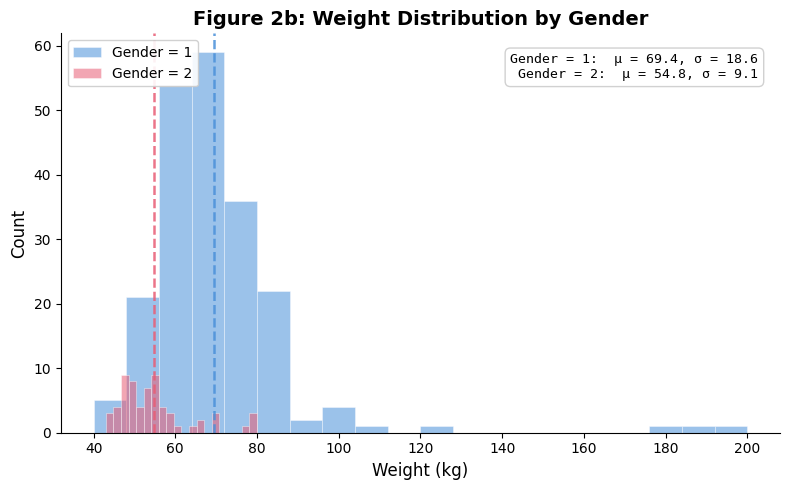


📌 [4] 繪製文本特徵 (self_intro) 的性別高頻詞差異...


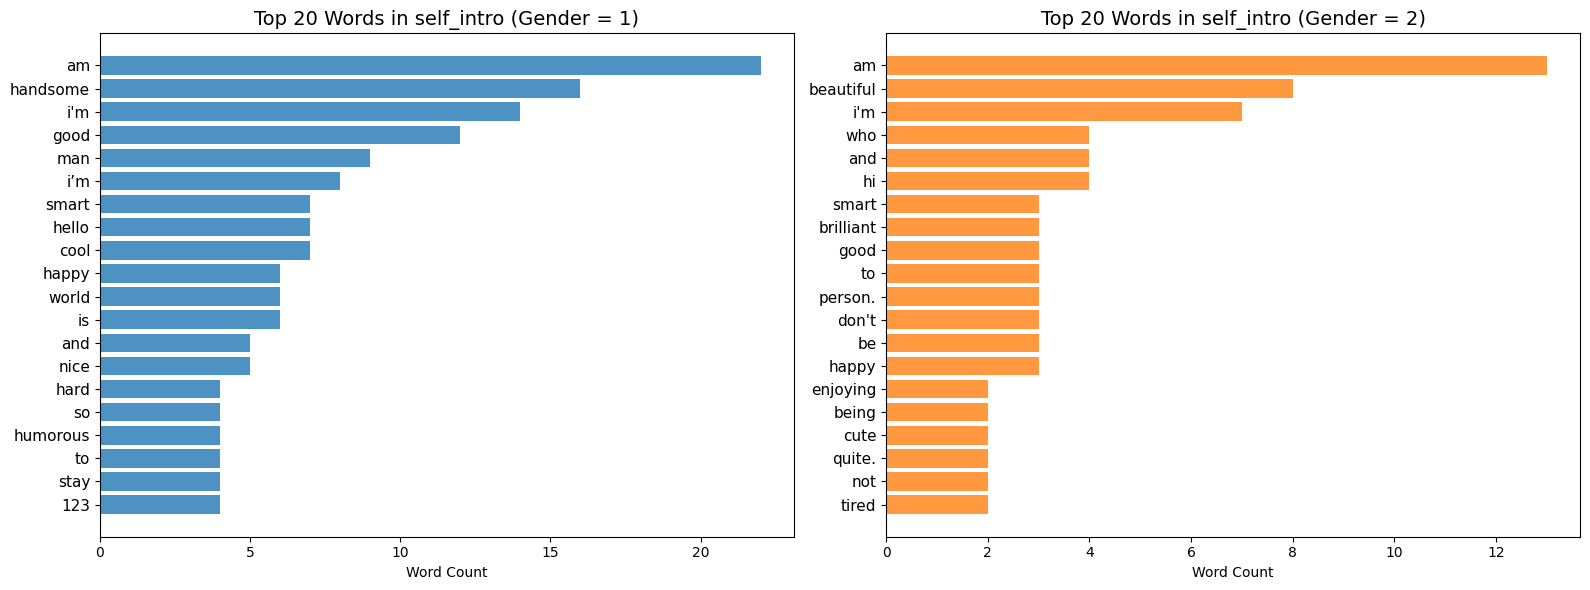


📌 [5] 執行 Mutual Information (MI) 評估並繪製長條圖...


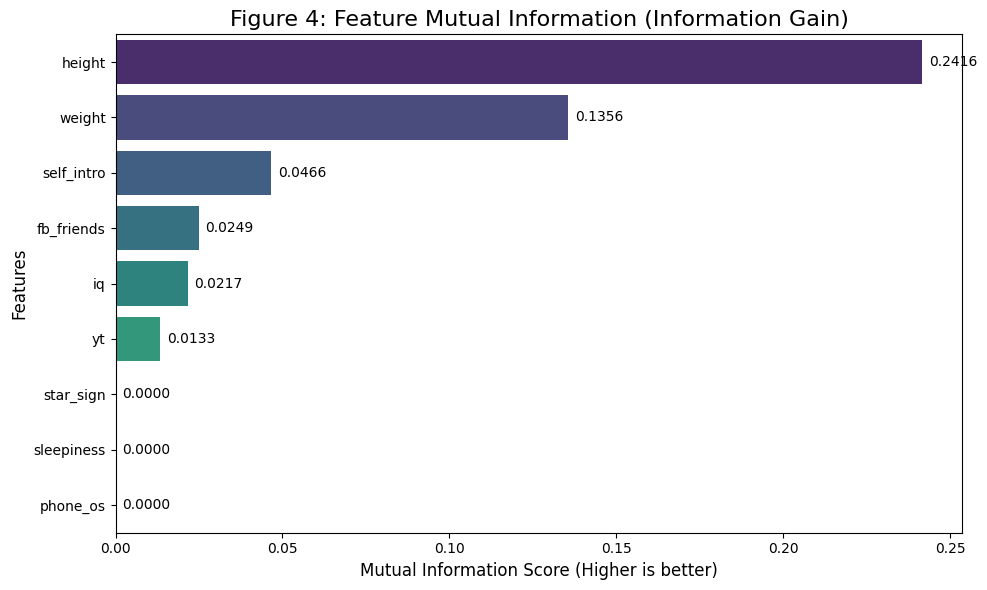

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# =============================================================================
# [1] Figure 1: 原始 Train / Test 缺失率對照圖 (Grouped Horizontal Bar Chart)
# =============================================================================
print("📌 [1] 分析原始資料缺失狀態並繪製對照圖...")

# 計算缺失率
train_miss_pct = (train_df.isnull().sum() / len(train_df) * 100).round(1)
test_miss_pct = (test_df.isnull().sum() / len(test_df) * 100).round(1)

# 合併成一個 DataFrame 方便畫圖
miss_compare_df = pd.DataFrame({
    'Train Missing Rate (%)': train_miss_pct,
    'Test Missing Rate (%)': test_miss_pct
})

# 繪製 Grouped Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(10, 7))
miss_compare_df.plot(kind='barh', ax=ax, color=['#1f77b4', '#ff7f0e'], width=0.7, alpha=0.8)

plt.title('Missing Rates Comparison (Train vs Test)', fontsize=16)
plt.xlabel('Missing Rate (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.gca().invert_yaxis() # 讓圖表由上往下排列

# 在長條圖旁邊加上數值標籤
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 0.5, p.get_y() + p.get_height() / 2, f'{width}%', 
                 va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

# =============================================================================
# [2.1] Display Table 2: Physical Boundary Filtering Thresholds
# =============================================================================
print("\n📌 [2.1] Defining physical boundaries (Values outside these ranges will be set to NaN)...")

# 建立門檻設定表格資料 (英文版)
bounds_data = {
    'Feature': ['height', 'weight', 'iq', 'sleepiness', 'fb_friends', 'yt'],
    'Min Bound': ['100 cm', '30 kg', '50', '0 hr', '0', '0'],
    'Max Bound': ['250 cm', '200 kg', '200', '24 hr', 'None', 'None (V4: Dynamic 99th Percentile)'],
    'Rationale': [
        'Exclude negative values and extreme outliers (e.g., 1e+111)', 
        'Exclude negative values and extreme outliers', 
        'Reasonable human IQ range', 
        'Maximum 24 hours in a day', 
        'Exclude negative friend counts', 
        'Exclude Excel errors (#NUM!) and negative values'
    ]
}

# 轉換成 DataFrame 並顯示
bounds_df = pd.DataFrame(bounds_data)
# 設定索引不要顯示，讓表格看起來更乾淨
bounds_df.index = [''] * len(bounds_df) 

print("\n=== Table 2: Physical Boundary Filtering Thresholds by Feature ===")
display(bounds_df)
# =============================================================================
# [3] Figure 2a & 2b: 獨立繪製 Height 與 Weight 的性別分佈
# =============================================================================
print("\n📌 [3] 分別繪製 Height 與 Weight 的性別分佈...")

# 確保使用我們清洗過後的 train_df
df_clean_plot = train_df.dropna(subset=['height', 'weight']) 

colors = {1: '#4A90D9', 2: '#E85D75'} # 質感藍與玫瑰紅
labels = {1: 'Gender = 1', 2: 'Gender = 2'}

# 定義要畫的兩個特徵與標題
features_to_plot = [
    ('height', '(cm)', 'Figure 2a: Height Distribution by Gender'),
    ('weight', '(kg)', 'Figure 2b: Weight Distribution by Gender')
]

for col, unit, title in features_to_plot:
    # 每次迴圈都建立一張全新的獨立圖表
    fig, ax = plt.subplots(figsize=(8, 5)) 
    stats = {}
    
    for gender, grp in df_clean_plot.groupby('gender'):
        vals = grp[col].dropna()
        
        # 繪製直方圖
        ax.hist(vals, bins=20, alpha=0.55, label=labels[gender],
                color=colors[gender], edgecolor='white', linewidth=0.5)
        
        m, s = vals.mean(), vals.std()
        stats[gender] = (m, s)
        
        # 垂直虛線標示均值位置
        ax.axvline(m, color=colors[gender], linestyle='--', linewidth=1.8, alpha=0.85)
    
    # 右上角統計 box (顯示 μ 與 σ)
    stat_text = (
        f"{labels[1]}:  μ = {stats[1][0]:.1f}, σ = {stats[1][1]:.1f}\n"
        f"{labels[2]}:  μ = {stats[2][0]:.1f}, σ = {stats[2][1]:.1f}"
    )
    ax.text(0.97, 0.95, stat_text, transform=ax.transAxes,
            fontsize=9.5, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.9),
            fontfamily='monospace')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'{col.capitalize()} {unit}', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    
    # 移除頂部與右側邊框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    # 每次畫完一張就顯示出來，這樣就會變成上下分開的兩張圖
    plt.show()
# =============================================================================
# [4] Figure 3: self_intro 分性別 Top-20 高頻詞
# =============================================================================
print("\n📌 [4] 繪製文本特徵 (self_intro) 的性別高頻詞差異...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {1: '#1f77b4', 2: '#ff7f0e'} 

for idx, gender in enumerate([1, 2]):
    texts = train_df[train_df['gender']==gender]['self_intro'].dropna() 
    words = ' '.join(texts).lower().split()
    words = [w for w in words if len(w) > 1] 
    top20 = Counter(words).most_common(20)
    
    labels, counts = zip(*top20)
    axes[idx].barh(range(len(labels)), counts, color=colors[gender], alpha=0.8)
    axes[idx].set_yticks(range(len(labels)))
    axes[idx].set_yticklabels(labels, fontsize=11)
    axes[idx].invert_yaxis()  
    axes[idx].set_title(f'Top 20 Words in self_intro (Gender = {gender})', fontsize=14)
    axes[idx].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# =============================================================================
# [5] Figure 4: Mutual Information (MI) 資訊增益長條圖
# =============================================================================
print("\n📌 [5] 執行 Mutual Information (MI) 評估並繪製長條圖...")

df_imputed = train_df.copy() 

# === 🛠️ 修正點：強制轉為數值後再算中位數 ===
for col in ['height', 'weight', 'iq', 'sleepiness', 'fb_friends', 'yt']:
    df_imputed[col] = pd.to_numeric(df_imputed[col], errors='coerce') # 強制轉數值
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())

for col in ['star_sign', 'phone_os', 'self_intro']:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])
    df_imputed[col] = LabelEncoder().fit_transform(df_imputed[col].astype(str))

X_mi = df_imputed.drop(columns=['id', 'gender'])
y_mi = df_imputed['gender']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, hue=mi_scores_series.index, palette='viridis', legend=False)

plt.title('Figure 4: Feature Mutual Information (Information Gain)', fontsize=16)
plt.xlabel('Mutual Information Score (Higher is better)', fontsize=12)
plt.ylabel('Features', fontsize=12)

for i, v in enumerate(mi_scores_series.values):
    plt.text(v + 0.002, i, f"{v:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [4]:
# ---------------------------------------------------------
# Cell 2: 基礎資料清洗、極端值防禦與 Target Encoding
# ---------------------------------------------------------


# 2. 清理 phone_os 噪音值
def clean_os(val):
    val = str(val).lower()
    if 'apple' in val or 'ios' in val: return 'Apple'
    if 'android' in val: return 'Android'
    return 'Other'

train_df['phone_os'] = train_df['phone_os'].apply(clean_os)
test_df['phone_os'] = test_df['phone_os'].apply(clean_os)

# 🚀 修正：計算 99 百分位數作為 yt 合理上限
train_df['yt'] = pd.to_numeric(train_df['yt'], errors='coerce')
yt_99_percentile = train_df['yt'].dropna().quantile(0.99)
print(f"yt 欄位 99% 上限設定為: {yt_99_percentile:.0f}")

# 3. 物理邊界強化 (嚴格過濾極端值，防溢位)
def apply_advanced_bounds(df):
    df_clean = df.copy()
    df_clean['yt'] = pd.to_numeric(df_clean['yt'], errors='coerce')
    df_clean['height'] = df_clean['height'].apply(lambda x: x if 100 <= x <= 250 else np.nan)
    df_clean['weight'] = df_clean['weight'].apply(lambda x: x if 30 <= x <= 200 else np.nan)
    df_clean['iq'] = df_clean['iq'].apply(lambda x: x if 50 <= x <= 200 else np.nan)
    df_clean['sleepiness'] = df_clean['sleepiness'].apply(lambda x: x if 0 <= x <= 24 else np.nan)
    df_clean['fb_friends'] = df_clean['fb_friends'].apply(lambda x: x if 0 <= x <= 5000 else np.nan)
    # 🚀 修正：使用 99 百分位數取代原本寬鬆的 1e15
    df_clean['yt'] = df_clean['yt'].apply(lambda x: x if 0 <= x <= yt_99_percentile else np.nan)
    return df_clean

train_df = apply_advanced_bounds(train_df)
test_df = apply_advanced_bounds(test_df)

# 4. 保留類別特徵
X = train_df.drop(columns=['id', 'gender', 'self_intro'])
y = train_df['gender']
X_test_submission = test_df.drop(columns=['id', 'gender', 'self_intro'])
test_ids = test_df['id']

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# 🚨 修正：為防止 Target Encoding 洩漏，原本的 fit_transform 已移至 Cell 4 的防漏函數內
# print("執行 Target Encoding (Smoothing=20)...")
# te = TargetEncoder(cols=['star_sign', 'phone_os'], smoothing=20)
# X = te.fit_transform(X, y_encoded)
# X_test_submission = te.transform(X_test_submission)
print("📌 Target Encoding 已延後至 CV 內部執行以防止 Data Leakage。")

# 5. 建立缺失值指示器 (保留重要的缺失資訊)
for col in ['weight', 'height', 'yt']:
    X[f'{col}_is_missing'] = X[col].isnull().astype(int)
    X_test_submission[f'{col}_is_missing'] = X_test_submission[col].isnull().astype(int)

print(f"✅ Cell 2 處理完成！目前特徵總數: {X.shape[1]}")

yt 欄位 99% 上限設定為: 99999
📌 Target Encoding 已延後至 CV 內部執行以防止 Data Leakage。
✅ Cell 2 處理完成！目前特徵總數: 11


In [5]:
# ---------------------------------------------------------
# Cell 3: 升級版 NLP 語意萃取 (BGE-Large) 與 PCA 降維
# ---------------------------------------------------------
print("載入 BGE-Large 模型擷取文字語意 (首次執行需下載模型)...")

# 🚀 修正：將 Prefix 設為空字串，避免扭曲分類任務的向量空間
prefix = ""
def process_text(text):
    if pd.isna(text) or str(text).strip() == '':
        return 'no description'
    return prefix + str(text)

train_texts = [process_text(t) for t in train_df['self_intro']]
test_texts = [process_text(t) for t in test_df['self_intro']]

# 🚀 升級武器 1：使用 BGE-Large 擷取深層語意
embedder = SentenceTransformer('BAAI/bge-large-en-v1.5')
train_emb = embedder.encode(train_texts, show_progress_bar=True)
test_emb = embedder.encode(test_texts, show_progress_bar=True)

print("📌 PCA 降維已延後至 CV 內部執行以防止 Data Leakage。")
print("✅ NLP 處理完成！(無 Prefix 純淨版)")

載入 BGE-Large 模型擷取文字語意 (首次執行需下載模型)...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 4491.46it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 14/14 [00:06<00:00,  2.21it/s]

📌 PCA 降維已延後至 CV 內部執行以防止 Data Leakage。
✅ NLP 處理完成！(無 Prefix 純淨版)


In [6]:
# ---------------------------------------------------------
# Cell 4: 隨機森林進階補值與特徵工程
# ---------------------------------------------------------
print("建立進階衍生特徵函數 ( BMI, 體型比例, Log Transform )...")

# 📌 完美保留你的特徵工程邏輯
def create_advanced_features(df):
    df_new = df.copy()
    
    # 1. 建立 BMI 特徵
    df_new['height'] = df_new['height'].clip(lower=1) 
    df_new['BMI'] = df_new['weight'] / ((df_new['height'] / 100) ** 2)
    
    # 2. 加入線性的身高體重比 (來自 Willy)
    df_new['height_weight_ratio'] = df_new['height'] / df_new['weight']
    
    # 3. 對極端右偏的數值進行 Log1p 轉換
    df_new['yt_log'] = np.log1p(df_new['yt'].clip(lower=0))
    df_new['fb_friends_log'] = np.log1p(df_new['fb_friends'].clip(lower=0))
    
    # 移除原始尚未 Log 的欄位
    df_new = df_new.drop(columns=['yt', 'fb_friends'])
    return df_new

def preprocess_fold(X_tr, y_tr, X_va, tr_emb, va_emb):
    X_tr, X_va = X_tr.copy(), X_va.copy()
    
    # (a) Target Encoding
    te = TargetEncoder(cols=['star_sign', 'phone_os'], smoothing=20)
    X_tr = te.fit_transform(X_tr, y_tr)
    X_va = te.transform(X_va)
    
    # 🚀 修正：(b) PCA 維度提升至 5 維 (迴圈同步改為 5)
    pca = PCA(n_components=5, random_state=42)
    tr_pca = pca.fit_transform(tr_emb)
    va_pca = pca.transform(va_emb)
    for i in range(5):
        X_tr[f'intro_pca_{i}'] = tr_pca[:, i]
        X_va[f'intro_pca_{i}'] = va_pca[:, i]
        
    # (c) Random Forest Imputer
    rf_imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1), 
        random_state=42, max_iter=10
    )
    X_tr_imp = pd.DataFrame(rf_imputer.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_va_imp = pd.DataFrame(rf_imputer.transform(X_va), columns=X_va.columns, index=X_va.index)
    
    # (d) 執行特徵工程
    return create_advanced_features(X_tr_imp), create_advanced_features(X_va_imp)

print("✅ 預處理防漏生產線準備完成！(確保 Imputer 只看 Training Set)")

建立進階衍生特徵函數 ( BMI, 體型比例, Log Transform )...
✅ 預處理防漏生產線準備完成！(確保 Imputer 只看 Training Set)


🚀 升級武器 3：執行多次投票制 Permutation Importance 自動抓出噪聲特徵...
開始計算 5 輪的特徵重要性，請稍候...

🚫 成功移除「每一輪都被判定無用」的噪聲特徵: ['intro_pca_3', 'fb_friends_log']
✅ 保留核心特徵 (16 個): ['star_sign', 'phone_os', 'height', 'weight', 'sleepiness', 'iq', 'weight_is_missing', 'height_is_missing', 'yt_is_missing', 'intro_pca_0', 'intro_pca_1', 'intro_pca_2', 'intro_pca_4', 'BMI', 'height_weight_ratio', 'yt_log']

📊 正在繪製「特徵生存戰」投票結果圖表...


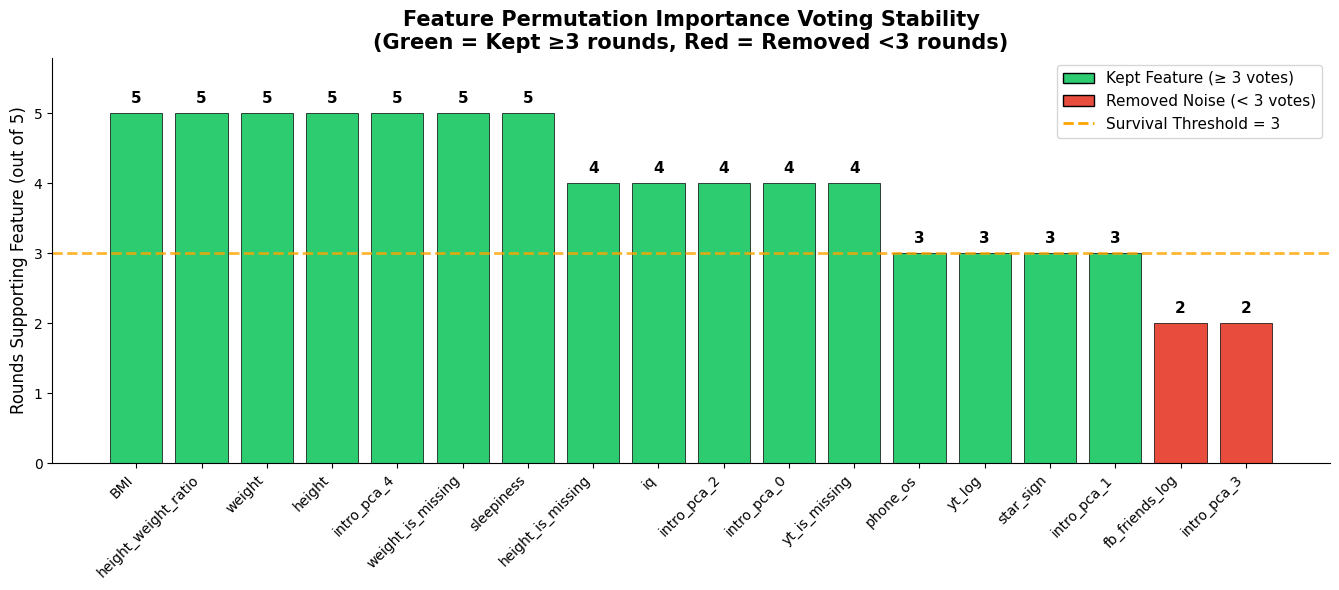

✅ 視覺化圖表已儲存至: ../results\feature_vote_counts.png


In [7]:
# ---------------------------------------------------------
# Cell 5: 科學化特徵淘汰 (多次投票制 Permutation Importance)
# ---------------------------------------------------------
print("🚀 升級武器 3：執行多次投票制 Permutation Importance 自動抓出噪聲特徵...")

# 使用 LightGBM 作為 PI 測試模型
lgbm_pi = LGBMClassifier(class_weight='balanced', random_state=42, max_depth=4, verbose=-1)

# 大師級建議：使用 5 個不同的亂數種子進行投票
seeds = [42, 123, 456, 789, 1024]
all_keep_masks = []
features = None

print(f"開始計算 {len(seeds)} 輪的特徵重要性，請稍候...")

for seed in seeds:
    cv_pi = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    perm_scores_this_round = []
    
    for tr_idx, val_idx in cv_pi.split(X, y_encoded):
        X_tr, y_tr = X.iloc[tr_idx], y_encoded[tr_idx]
        X_val, y_val = X.iloc[val_idx], y_encoded[val_idx]
        tr_emb, val_emb = train_emb[tr_idx], train_emb[val_idx]
        
        # 嚴格防漏預處理
        X_tr_eng, X_val_eng = preprocess_fold(X_tr, y_tr, X_val, tr_emb, val_emb)
        if features is None: features = X_tr_eng.columns
        
        lgbm_pi.fit(X_tr_eng, y_tr)
        
        # 計算這一個 Fold 的特徵重要性
        result = permutation_importance(
            lgbm_pi, X_val_eng, y_val,
            n_repeats=10, random_state=seed, scoring='roc_auc'
        )
        perm_scores_this_round.append(result.importances_mean)
        
    # 算出這一個 Seed (5-Fold 平均) 的分數
    round_mean = np.mean(perm_scores_this_round, axis=0)
    all_keep_masks.append(round_mean > 0)

# 🚀 只要有任何一輪認為有用，就保留 (np.any)
final_keep_mask = np.sum(all_keep_masks, axis=0) >= 3

removed_features = [features[i] for i in range(len(features)) if not final_keep_mask[i]]
kept_features = [features[i] for i in range(len(features)) if final_keep_mask[i]]

print(f"\n🚫 成功移除「每一輪都被判定無用」的噪聲特徵: {removed_features}")
print(f"✅ 保留核心特徵 ({len(kept_features)} 個): {kept_features}")

# ---------------------------------------------------------
# 📊 [視覺化] 各特徵在 5 輪中獲得幾輪支持 (Voting Stability)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

print("\n📊 正在繪製「特徵生存戰」投票結果圖表...")

# 計算每個特徵獲得的總票數
vote_counts = np.sum(all_keep_masks, axis=0)  # shape: (n_features,)
feature_names = list(features)

# 依照票數由高到低排序，讓圖表更好看
sorted_idx = np.argsort(vote_counts)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_votes = vote_counts[sorted_idx]

# 設定顏色：>=3 票為綠色 (保留)，<3 票為紅色 (淘汰)
colors = ['#2ecc71' if v >= 3 else '#e74c3c' for v in sorted_votes]

# 建立畫布
fig, ax = plt.subplots(figsize=(max(12, len(sorted_names) * 0.75), 6))
bars = ax.bar(range(len(sorted_names)), sorted_votes, color=colors, edgecolor='black', linewidth=0.5)

# 在每根柱子上方標示票數
for bar, v in zip(bars, sorted_votes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(int(v)), ha='center', va='bottom', fontsize=11, fontweight='bold')

# 畫出 threshold 生死線 (3 票)
ax.axhline(y=3, color='orange', linestyle='--', linewidth=2, alpha=0.8)

# 設定座標軸與標題
ax.set_xticks(range(len(sorted_names)))
ax.set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(6))
ax.set_ylabel('Rounds Supporting Feature (out of 5)', fontsize=12)
ax.set_title('Feature Permutation Importance Voting Stability\n(Green = Kept ≥3 rounds, Red = Removed <3 rounds)', fontsize=15, fontweight='bold')

# 自訂圖例 (Legend)
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Kept Feature (≥ 3 votes)'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Removed Noise (< 3 votes)'),
    plt.Line2D([0], [0], color='orange', linestyle='--', linewidth=2, label='Survival Threshold = 3'),
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper right')

# 讓 Y 軸上方多一點空間給數字
ax.set_ylim(0, 5.8)

# 移除上右邊框，增加專業感
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 安全地儲存圖片 (確保資料夾存在)
output_dir = '../results'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
save_path = os.path.join(output_dir, 'feature_vote_counts.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')

plt.show()
print(f"✅ 視覺化圖表已儲存至: {save_path}")

In [8]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score
from category_encoders import TargetEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

print("🏆 啟動補值天王大對決 (Imputation Ablation Study - True V4 Pipeline) 🏆\n")

# =====================================================================
# 計算 XGBoost 專用的 scale_pos_weight (根據你原本 V4 的邏輯)
# gender 1 數量 vs gender 2 數量
# =====================================================================
ratio = float(np.sum(y_encoded == 0)) / np.sum(y_encoded == 1)

# =====================================================================
# 🛠️ 解決狀態殘留 (State Leakage)：使用 Factory Function
# =====================================================================
def get_imputers():
    return {
        "1. Simple Imputer (Median)": SimpleImputer(strategy='median'),
        "2. KNN Imputer (k=5)": KNNImputer(n_neighbors=5),
        "3. LightGBM Imputer": IterativeImputer(
            estimator=lgb.LGBMRegressor(n_estimators=50, random_state=42, max_depth=5, verbose=-1), 
            random_state=42, max_iter=10
        ),
        "4. Random Forest Imputer (V4)": IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=50, random_state=42, max_depth=5, n_jobs=-1), 
            random_state=42, max_iter=10
        )
    }

# =====================================================================
# 🛠️ 確保使用與 V4 完全一致的預處理管線
# =====================================================================
def preprocess_fold_ablation(X_tr, y_tr_enc, X_va, tr_emb_fold, va_emb_fold, current_imputer):
    X_tr, X_va = X_tr.copy(), X_va.copy()
    
    # (a) Target Encoding
    te = TargetEncoder(cols=['star_sign', 'phone_os'], smoothing=20)
    X_tr = te.fit_transform(X_tr, y_tr_enc)
    X_va = te.transform(X_va)
    
    # (b) PCA (在補值前加入)
    pca = PCA(n_components=5, random_state=42)
    tr_pca = pca.fit_transform(tr_emb_fold)
    va_pca = pca.transform(va_emb_fold)
    for i in range(5):
        X_tr[f'intro_pca_{i}'] = tr_pca[:, i]
        X_va[f'intro_pca_{i}'] = va_pca[:, i]
        
    # (c) Imputation
    X_tr_imp = pd.DataFrame(
        current_imputer.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_va_imp = pd.DataFrame(
        current_imputer.transform(X_va), columns=X_va.columns, index=X_va.index)
        
    # (d) Feature Engineering
    return create_advanced_features(X_tr_imp), create_advanced_features(X_va_imp)

# =====================================================================
# ⚔️ 開始 10-Fold 擂台賽
# =====================================================================
results = []
skf_ablation = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

imputer_names = list(get_imputers().keys())

for imputer_name in imputer_names:
    print(f"⏳ 正在測試: {imputer_name} ...")
    
    fold_auc = []
    fold_f1 = []
    
    for fold, (train_idx, val_idx) in enumerate(skf_ablation.split(X, y_encoded)):
        X_tr, y_tr_enc = X.iloc[train_idx].copy(), y_encoded[train_idx].copy()
        X_va, y_va_enc = X.iloc[val_idx].copy(), y_encoded[val_idx].copy()
        tr_emb_fold, va_emb_fold = train_emb[train_idx], train_emb[val_idx]
        
        fresh_imputer = get_imputers()[imputer_name]
        
        X_tr_final, X_va_final = preprocess_fold_ablation(
            X_tr, y_tr_enc, X_va, tr_emb_fold, va_emb_fold, fresh_imputer
        )
        
        X_tr_final = X_tr_final[kept_features]
        X_va_final = X_va_final[kept_features]
        
        # 🛡️ 修正：直接使用 'balanced' 與計算好的 ratio
        eval_model = StackingClassifier(
            estimators=[
                ('XGB', xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, min_child_weight=1, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=ratio, random_state=42, n_jobs=-1, eval_metric='logloss')),
                ('LGBM', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=7, min_child_samples=10, colsample_bytree=0.8, subsample=0.8, class_weight='balanced', random_state=42, verbose=-1)),
                ('RF', RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1))
            ],
            final_estimator=LogisticRegression(class_weight='balanced', random_state=42)
        )
        
        eval_model.fit(X_tr_final, y_tr_enc)
        preds_proba = eval_model.predict_proba(X_va_final)[:, 1]
        preds_class = eval_model.predict(X_va_final)
        
        fold_auc.append(roc_auc_score(y_va_enc, preds_proba))
        fold_f1.append(f1_score(y_va_enc, preds_class, pos_label=1))
        
    mean_auc = np.mean(fold_auc)
    std_auc = np.std(fold_auc)
    mean_f1 = np.mean(fold_f1)
    
    results.append({
        'Imputation Strategy': imputer_name,
        'ROC-AUC (10-Fold)': f"{mean_auc:.4f} (±{std_auc:.4f})",
        'F1-Score (Macro)': f"{mean_f1:.4f}"
    })

results_df = pd.DataFrame(results)
results_df.set_index('Imputation Strategy', inplace=True)

print("\n📊 === 補值方法對決最終成績單 === 📊")
display(results_df)

🏆 啟動補值天王大對決 (Imputation Ablation Study - True V4 Pipeline) 🏆

⏳ 正在測試: 1. Simple Imputer (Median) ...
⏳ 正在測試: 2. KNN Imputer (k=5) ...
⏳ 正在測試: 3. LightGBM Imputer ...
⏳ 正在測試: 4. Random Forest Imputer (V4) ...

📊 === 補值方法對決最終成績單 === 📊


,ROC-AUC (10-Fold),F1-Score (Macro)
Imputation Strategy,,
1. Simple Imputer (Median),0.9319 (±0.0607),0.7720
2. KNN Imputer (k=5),0.9317 (±0.0639),0.7861
3. LightGBM Imputer,0.9308 (±0.0702),0.7943
4. Random Forest Imputer (V4),0.9227 (±0.0727),0.7702


In [9]:
# ---------------------------------------------------------
# Cell 6: 三檔位融合 (Blending) 驗證與綜合評估
# ---------------------------------------------------------
print("啟動大師級融合策略：手動三檔位 Blending (目標: 中和過擬合，極大化穩定性)...")

ratio = (y_encoded == 0).sum() / (y_encoded == 1).sum()

# 🚀 定義三組不同「性格」的參數
configs = {
    'Conservative (保守)': {
        'xgb': {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 150, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 5.0},
        'lgbm': {'max_depth': 3, 'num_leaves': 15, 'learning_rate': 0.05, 'n_estimators': 150},
        'rf': {'max_depth': 4, 'n_estimators': 150, 'min_samples_leaf': 4}
    },
    'Moderate (中庸)': {
        'xgb': {'max_depth': 5, 'learning_rate': 0.03, 'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0},
        'lgbm': {'max_depth': 5, 'num_leaves': 31, 'learning_rate': 0.03, 'n_estimators': 200},
        'rf': {'max_depth': 6, 'n_estimators': 200, 'min_samples_leaf': 2}
    },
    'Aggressive (激進)': {
        'xgb': {'max_depth': 7, 'learning_rate': 0.01, 'n_estimators': 300, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 0.1},
        'lgbm': {'max_depth': 7, 'num_leaves': 63, 'learning_rate': 0.01, 'n_estimators': 300},
        'rf': {'max_depth': 8, 'n_estimators': 300, 'min_samples_leaf': 1}
    }
}

# ==========================================
# 預先計算 10-Fold 防漏資料 (加速神技)
# ==========================================
print("⏳ 預先計算 10-Fold 防漏資料 (只算一次，確保完全零洩漏)...")
skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
precomputed_10_folds = []

for tr_idx, val_idx in skf_10.split(X, y_encoded):
    X_tr, y_tr = X.iloc[tr_idx], y_encoded[tr_idx]
    X_va, y_va = X.iloc[val_idx], y_encoded[val_idx]
    tr_emb, va_emb = train_emb[tr_idx], train_emb[val_idx]
    
    X_tr_eng, X_va_eng = preprocess_fold(X_tr, y_tr, X_va, tr_emb, va_emb)
    X_tr_pruned, X_va_pruned = X_tr_eng[kept_features], X_va_eng[kept_features]
    precomputed_10_folds.append((X_tr_pruned, y_tr, X_va_pruned, y_va))

print("✅ 10-Fold 資料準備完成！開始執行 Blending 融合評估...\n")

acc_list, auc_list, f1_list, logloss_list = [], [], [], []

# 在每一個 Fold 裡面，同時訓練三個模型並平均它們的機率
fold_count = 1
for X_tr_p, y_tr_p, X_va_p, y_va_p in precomputed_10_folds:
    print(f"訓練 Fold {fold_count}/10 ...")
    fold_probs = []
    
    for name, cfg in configs.items():
        xgb_clf = XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', random_state=42, tree_method='hist', device='cuda', **cfg['xgb'])
        lgbm_clf = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, **cfg['lgbm'])
        rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, **cfg['rf'])
        
        model = StackingClassifier(
            estimators=[('XGB', xgb_clf), ('LGBM', lgbm_clf), ('RF', rf_clf)],
            final_estimator=LogisticRegression(class_weight='balanced', random_state=42)
        )
        
        model.fit(X_tr_p, y_tr_p)
        fold_probs.append(model.predict_proba(X_va_p))
    
    # 🚀 核心融合魔法：將三個模型的預測機率直接相加除以 3
    blended_prob = np.mean(fold_probs, axis=0)
    blended_class = np.argmax(blended_prob, axis=1)  # 機率大的那一邊獲勝
    
    acc_list.append(accuracy_score(y_va_p, blended_class))
    auc_list.append(roc_auc_score(y_va_p, blended_prob[:, 1]))
    f1_list.append(f1_score(y_va_p, blended_class))
    logloss_list.append(log_loss(y_va_p, blended_prob))
    
    fold_count += 1

print("\n🏆 三神融合 (Blending) 評估完成！")

print("\n📊 === Ultimate 終極融合版 Blending 10-Fold CV 綜合評估報告 ===")
print(f"Accuracy (準確率) : {np.mean(acc_list):.4f} (std: {np.std(acc_list):.4f})")
print(f"ROC-AUC  (排序力) : {np.mean(auc_list):.4f} (std: {np.std(auc_list):.4f})")
print(f"F1-Score (平衡度) : {np.mean(f1_list):.4f} (std: {np.std(f1_list):.4f})")
print(f"Log Loss (誤差值) : {np.mean(logloss_list):.4f} (std: {np.std(logloss_list):.4f})")

啟動大師級融合策略：手動三檔位 Blending (目標: 中和過擬合，極大化穩定性)...
⏳ 預先計算 10-Fold 防漏資料 (只算一次，確保完全零洩漏)...
✅ 10-Fold 資料準備完成！開始執行 Blending 融合評估...

訓練 Fold 1/10 ...
訓練 Fold 2/10 ...
訓練 Fold 3/10 ...
訓練 Fold 4/10 ...
訓練 Fold 5/10 ...
訓練 Fold 6/10 ...
訓練 Fold 7/10 ...
訓練 Fold 8/10 ...
訓練 Fold 9/10 ...
訓練 Fold 10/10 ...

🏆 三神融合 (Blending) 評估完成！

📊 === Ultimate 終極融合版 Blending 10-Fold CV 綜合評估報告 ===
Accuracy (準確率) : 0.8792 (std: 0.0559)
ROC-AUC  (排序力) : 0.9215 (std: 0.0750)
F1-Score (平衡度) : 0.7841 (std: 0.0908)
Log Loss (誤差值) : 0.3868 (std: 0.1163)


In [10]:
# ---------------------------------------------------------
# Cell 7: 終極融合版 (Blending) 預測與存檔
# ---------------------------------------------------------
print("正在將全局資料通過防漏生產線進行轉換...")
X_train_final, X_test_final = preprocess_fold(X, y_encoded, X_test_submission, train_emb, test_emb)

X_pruned = X_train_final[kept_features]
X_test_pruned = X_test_final[kept_features]

print(f"目前訓練集特徵數: {X_pruned.shape[1]}") 
print(f"目前測試集特徵數: {X_test_pruned.shape[1]}") 

print("\n正式訓練三組 Ultimate Stacking 模型，並進行預測融合中...")
test_fold_probs = []

for name, cfg in configs.items():
    print(f"  -> 訓練並預測 {name} 模型...")
    xgb_clf = XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', random_state=42, tree_method='hist', device='cuda', **cfg['xgb'])
    lgbm_clf = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, **cfg['lgbm'])
    rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, **cfg['rf'])
    
    model = StackingClassifier(
        estimators=[('XGB', xgb_clf), ('LGBM', lgbm_clf), ('RF', rf_clf)],
        final_estimator=LogisticRegression(class_weight='balanced', random_state=42)
    )
    
    model.fit(X_pruned, y_encoded)
    test_fold_probs.append(model.predict_proba(X_test_pruned))

print("\n執行最終機率平均融合 (Blending)...")
# 🚀 融合三組預測機率
final_blended_prob = np.mean(test_fold_probs, axis=0)
test_predictions_encoded = np.argmax(final_blended_prob, axis=1)

# 將 0, 1 轉回原始的性別標籤
test_predictions_original = le_y.inverse_transform(test_predictions_encoded)

submission_df = pd.DataFrame({
    'id': test_ids, 
    'gender': test_predictions_original
})

output_dir = '../results'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

file_path = os.path.join(output_dir, 'submission_blending_ultimate.csv')
submission_df.to_csv(file_path, index=False)

print(f"🏆 終極融合版預測成功！檔案已儲存至: {file_path}")
print("前五筆預測結果：")
print(submission_df.head())

正在將全局資料通過防漏生產線進行轉換...
目前訓練集特徵數: 16
目前測試集特徵數: 16

正式訓練三組 Ultimate Stacking 模型，並進行預測融合中...
  -> 訓練並預測 Conservative (保守) 模型...
  -> 訓練並預測 Moderate (中庸) 模型...
  -> 訓練並預測 Aggressive (激進) 模型...

執行最終機率平均融合 (Blending)...
🏆 終極融合版預測成功！檔案已儲存至: ../results\submission_blending_ultimate.csv
前五筆預測結果：
   id  gender
0   1       1
1   2       1
2   3       2
3   4       1
4   5       2
